#**R1**

In [73]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import pandas as pd


URL1="https://raw.githubusercontent.com/premlatamd/week02/refs/heads/main/images/sea2.jpeg"
URL2="https://raw.githubusercontent.com/premlatamd/week02/refs/heads/main/images/crowd.jpeg"
URL3="https://raw.githubusercontent.com/premlatamd/week02/refs/heads/main/images/saami.jpeg"


img_1 = Image.open(BytesIO(requests.get(URL1).content))
img_2 = Image.open(BytesIO(requests.get(URL2).content))
img_3 = Image.open(BytesIO(requests.get(URL3).content))



In [74]:
#Method1:
#Images were converted to grayscale using PIL's convert('L') function, which
#applies a standard luminance-based grayscale transformation.
#Y=0.299R+0.587G+0.114B
"""Luminance weights:
Red = 0.299
Green = 0.587
Blue = 0.114"""

img1 = img_1.convert("L")
img2 = img_2.convert("L")
img3 = img_3.convert("L")



In [75]:
A1 = np.array(img1, dtype=float)
A2 = np.array(img2, dtype=float)
A3 = np.array(img3, dtype=float)

In [76]:
#Method2:
#You can give the weights manually.
"""For experimentation, grayscale conversion was performed using custom weights
(0, 0, 1) instead of the standard luminance weights."""
img1_arr = np.array(img_1)
img2_arr = np.array(img_2)
img3_arr = np.array(img_3)

img_gray1= (
    0 * img1_arr[:,:,0] +
    0 * img1_arr[:,:,1] +
    1 * img1_arr[:,:,2]
)


img_gray2= (
    0 * img2_arr[:,:,0] +
    0 * img2_arr[:,:,1] +
    1 * img2_arr[:,:,2]
)

img_gray3= (
    0 * img3_arr[:,:,0] +
    0 * img3_arr[:,:,1] +
    1 * img3_arr[:,:,2]
)



In [77]:
print("Method 1 : Standard Luminance weights")
for i , A in enumerate([A1,A2,A3]):
  print(f"Shape of image{i+1} is : ",np.shape(A))
  m,n= np.shape(A)
  print(f"The size of image{i+1} is {m*n}")
  print('\n')

print("Method 2 : Custom Weights (0, 0, 1)\n")
for i , A in enumerate([img_gray1,img_gray2,img_gray3]):
  print(f"Shape of image{i+1} is : ",np.shape(A))
  m,n= np.shape(A)
  print(f"The size of image{i+1} is {m*n}")
  print('\n')

Method 1 : Standard Luminance weights
Shape of image1 is :  (678, 452)
The size of image1 is 306456


Shape of image2 is :  (332, 637)
The size of image2 is 211484


Shape of image3 is :  (1600, 1200)
The size of image3 is 1920000


Method 2 : Custom Weights (0, 0, 1)

Shape of image1 is :  (678, 452)
The size of image1 is 306456


Shape of image2 is :  (332, 637)
The size of image2 is 211484


Shape of image3 is :  (1600, 1200)
The size of image3 is 1920000




Method 1 : Standard Luminance weights


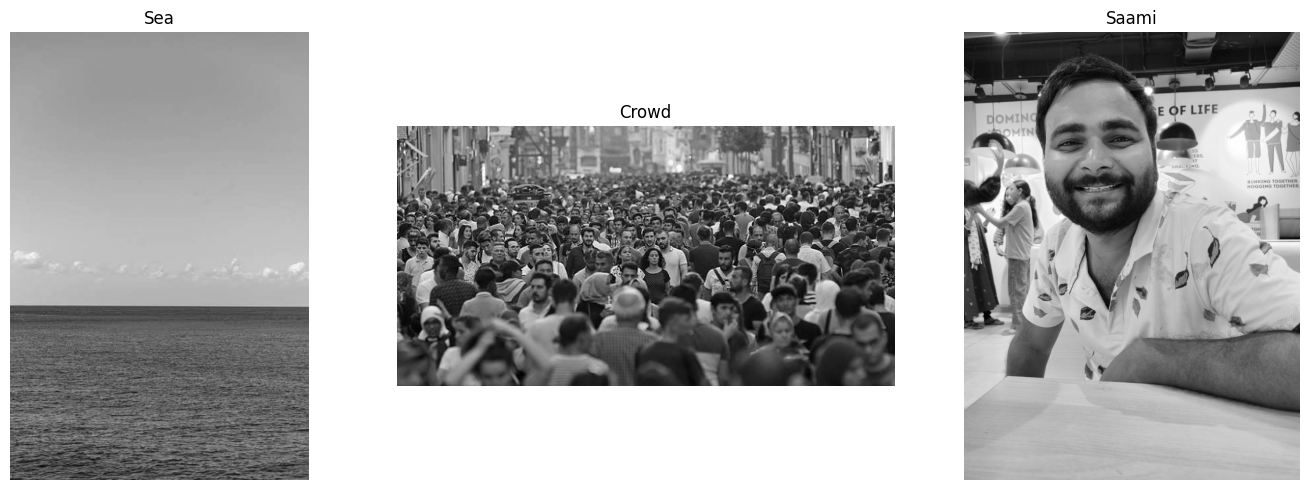

Method 2 : Custom Weights (0, 0, 1)



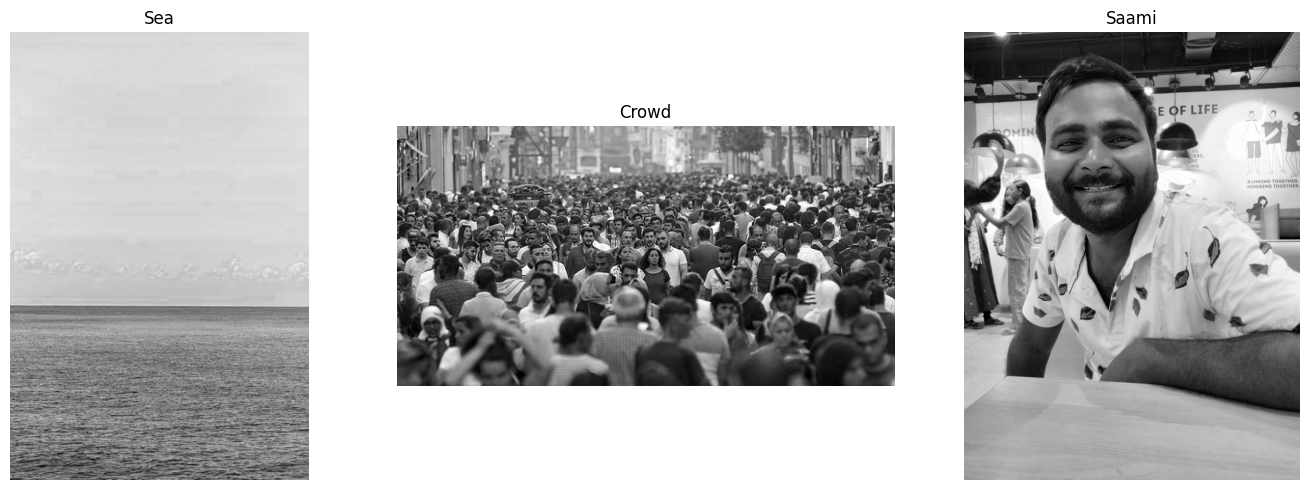

In [78]:
print("Method 1 : Standard Luminance weights")
images = [A1, A2, A3]
titles = ["Sea", "Crowd", "Saami"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Method 2 : Custom Weights (0, 0, 1)\n")

images = [img_gray1,img_gray2,img_gray3]
titles = ["Sea", "Crowd", "Saami"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

#**R2**

Max Error = 5.283595783112105e-11
Full Rank Check = True


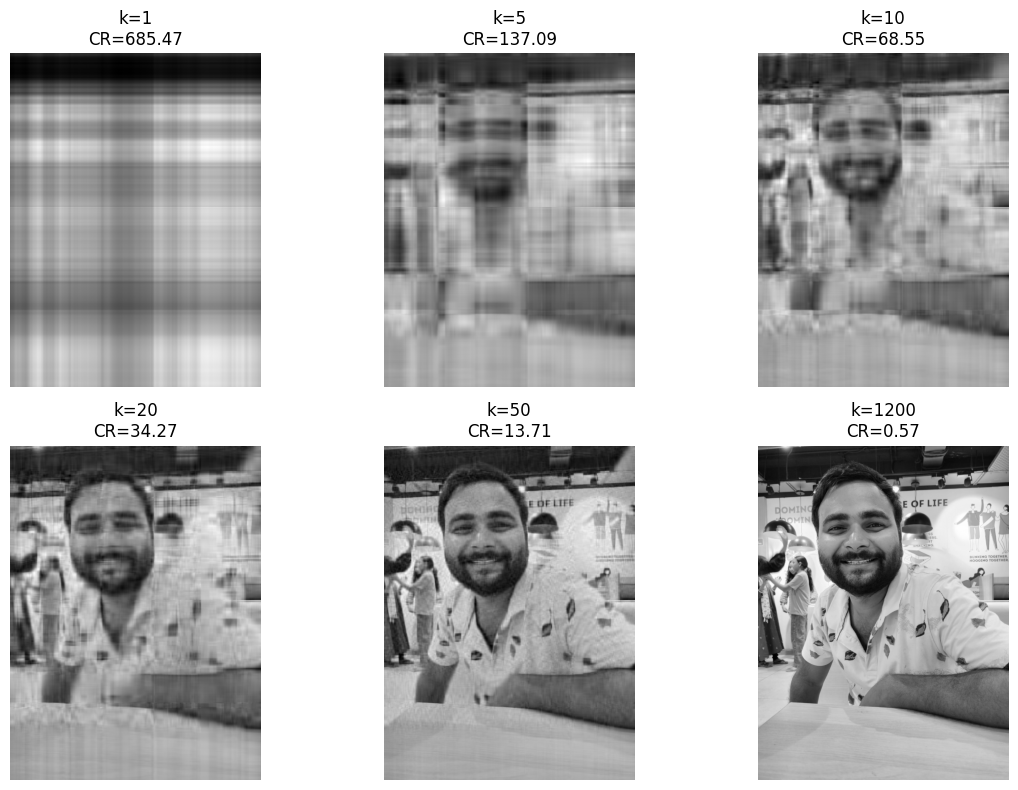

In [79]:
img = Image.open(BytesIO(requests.get(URL3).content))
img = np.array(img)

if img.ndim == 3:
    img = img.mean(axis=2)

m, n = img.shape
U, S, VT = np.linalg.svd(img, full_matrices=False)

A_full = U @ np.diag(S) @ VT

print("Max Error =", np.max(np.abs(img - A_full)))
print("Full Rank Check =", np.allclose(img, A_full, atol=1e-8))

# Required k values
k_values = [1, 5, 10, 20, 50, len(S)]
fig, axes = plt.subplots(2, 3, figsize=(12,8))

for ax, k in zip(axes.ravel(), k_values):
    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    VTk = VT[:k, :]

    Ak = Uk @ Sk @ VTk

    compression_ratio = (m*n) / (k*(m+n+1))

    ax.imshow(Ak, cmap="gray")
    ax.set_title(f"k={k}\nCR={compression_ratio:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

#**R3**

In [80]:
results = []
break_even_k = (m*n) / (m+n+1)

for k in [1,5,10,20,50,len(S)]:
    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    VTk = VT[:k, :]

    Ak = Uk @ Sk @ VTk
    numbers_stored = k * (m + n + 1)

    compression_ratio = (m*n) / numbers_stored

    # Relative error
    relative_error = (np.linalg.norm(img - Ak, 'fro')/ np.linalg.norm(img, 'fro'))

    # Energy retained
    energy_retained = (np.sum(S[:k]**2)/ np.sum(S**2))

    results.append([
        k,
        numbers_stored,
        compression_ratio,
        relative_error,
        energy_retained
    ])

df = pd.DataFrame(
    results,
    columns=[
        "k",
        "Numbers Stored",
        "Compression Ratio",
        "Relative Error",
        "Energy Retained"
    ]
)

print(df)
print("\nBreak-even k =", break_even_k)

      k  Numbers Stored  Compression Ratio  Relative Error  Energy Retained
0     1            2801         685.469475    3.134239e-01         0.901765
1     5           14005         137.093895    1.971728e-01         0.961123
2    10           28010          68.546948    1.467806e-01         0.978455
3    20           56020          34.273474    9.966070e-02         0.990068
4    50          140050          13.709390    5.498640e-02         0.996976
5  1200         3361200           0.571225    3.871020e-15         1.000000

Break-even k = 685.4694751874331


#**R4 — Choosing k**
1. Energy Thresold

In [81]:
energy = np.cumsum(S**2) / np.sum(S**2)

k90 = np.argmax(energy >= 0.90) + 1
k99 = np.argmax(energy >= 0.99) + 1
k999 = np.argmax(energy >= 0.999) + 1

print("k for 90% energy :", k90)
print("k for 99% energy :", k99)
print("k for 99.9% energy :", k999)

k for 90% energy : 1
k for 99% energy : 20
k for 99.9% energy : 103


2. Elbow Method

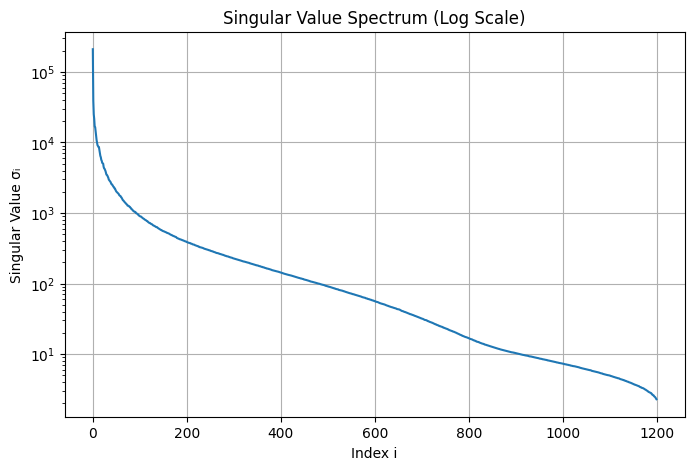

In [82]:
plt.figure(figsize=(8,5))

plt.semilogy(S)

plt.xlabel("Index i")
plt.ylabel("Singular Value σᵢ")
plt.title("Singular Value Spectrum (Log Scale)")
plt.grid()

plt.show()

3. Quality Target

In [83]:
quality_k = None

for k in range(1, len(S)+1):
    Ak = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]
    error = (np.linalg.norm(img - Ak, 'fro')/np.linalg.norm(img, 'fro'))

    if error < 0.05:
        quality_k = k
        break

print("Smallest k with error < 5% =",quality_k)

Smallest k with error < 5% = 57


#**R5**
- Compare Singular Value Spectra

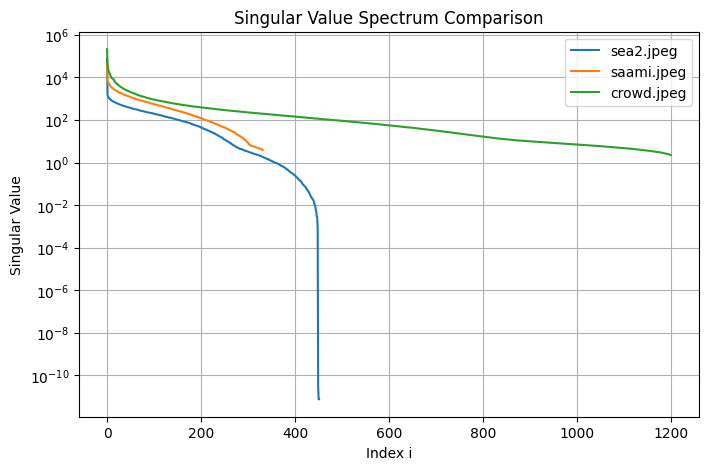

In [84]:
plt.figure(figsize=(8,5))

for img, name in [(img1, "sea2.jpeg"),(img2, "saami.jpeg"),(img3, "crowd.jpeg")]:
    U, S, VT = np.linalg.svd(img, full_matrices=False)
    plt.semilogy(S, label=name)

plt.xlabel("Index i")
plt.ylabel("Singular Value")
plt.title("Singular Value Spectrum Comparison")
plt.legend()
plt.grid()
plt.show()

In [85]:
noise1 = np.random.normal(0, 10, A1.shape)
noise2 = np.random.normal(0, 30, A1.shape)

A1_low_noise = A1 + noise1
A1_high_noise = A1 + noise2

In [86]:
U1, S1, VT1 = np.linalg.svd(A1_low_noise, full_matrices=False)

U2, S2, VT2 = np.linalg.svd(A1_high_noise, full_matrices=False)

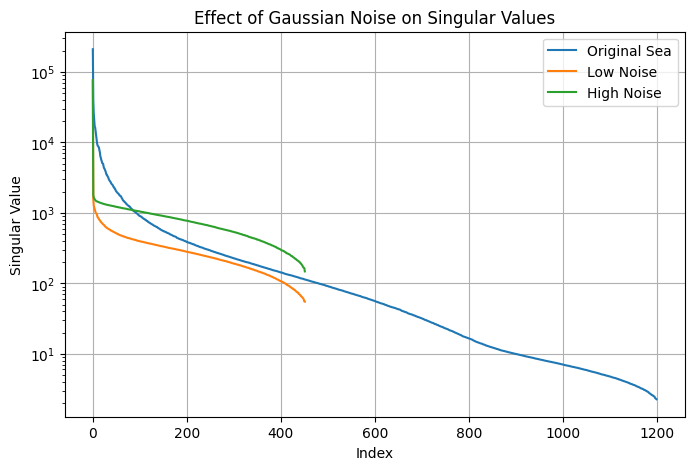

In [87]:
plt.figure(figsize=(8,5))

plt.semilogy(S, label="Original Sea")
plt.semilogy(S1, label="Low Noise")
plt.semilogy(S2, label="High Noise")

plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.title("Effect of Gaussian Noise on Singular Values")
plt.legend()
plt.grid()

plt.show()